Part 2.1 (PneumoniaMNIST)

In [ ]:
# Colab setup — install the dataset loader and the FID metric backend.
!pip install -q medmnist torchmetrics torch-fidelity

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, ConcatDataset
import torchvision.transforms as T
from torchvision.utils import make_grid
from medmnist import PneumoniaMNIST, INFO

SEED = 7
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# Global image / training constants.
IMG_CH   = 1     # PneumoniaMNIST is grayscale
IMG_SIZE = 28
Z_DIM    = 100   # latent vector length
BATCH    = 128

# --- consistent, clean plot styling for every figure in this notebook ---
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 11, "legend.fontsize": 9, "legend.framealpha": 0.9,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
})


Device: cuda


1. Load and explore the data


In [ ]:
# tanh-friendly normalisation to [-1, 1]
to_tensor = T.Compose([T.ToTensor(), T.Normalize((0.5,), (0.5,))])

train_set = PneumoniaMNIST(split="train", transform=to_tensor, download=True, size=28)
val_set   = PneumoniaMNIST(split="val",   transform=to_tensor, download=True, size=28)
test_set  = PneumoniaMNIST(split="test",  transform=to_tensor, download=True, size=28)

# Use every available image for unsupervised GAN training.
all_images = ConcatDataset([train_set, val_set, test_set])
CLASS_NAMES = list(INFO["pneumoniamnist"]["label"].values())
print("Classes:", CLASS_NAMES, "| total images:", len(all_images))

Classes: ['normal', 'pneumonia'] | total images: 5856


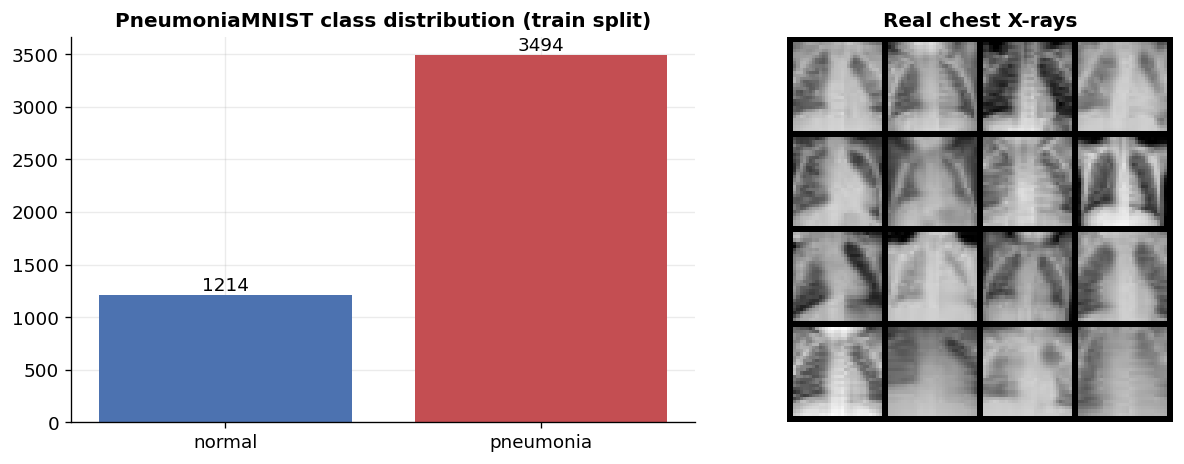

In [ ]:
# Class distribution (computed on the training split) + a grid of real samples.
train_labels = np.array([int(np.asarray(train_set[i][1]).item()) for i in range(len(train_set))])
counts = np.bincount(train_labels, minlength=len(CLASS_NAMES))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(CLASS_NAMES, counts, color=["#4c72b0", "#c44e52"])
ax[0].set_title("PneumoniaMNIST class distribution (train split)")
for i, c in enumerate(counts):
    ax[0].text(i, c, str(c), ha="center", va="bottom")

peek = torch.stack([all_images[i][0] for i in np.random.choice(len(all_images), 16, replace=False)])
grid = make_grid(peek, nrow=4, normalize=True, value_range=(-1, 1))
ax[1].imshow(grid.permute(1, 2, 0).numpy()[:, :, 0], cmap="gray")
ax[1].axis("off"); ax[1].set_title("Real chest X-rays")
plt.tight_layout(); plt.show()

2. DCGAN architecture


In [ ]:
def init_dcgan_weights(layer):
    """DCGAN weight init: conv/linear ~ N(0, 0.02), BatchNorm gamma ~ N(1, 0.02)."""
    kind = type(layer)
    if kind in (nn.Conv2d, nn.ConvTranspose2d, nn.Linear):
        nn.init.normal_(layer.weight, 0.0, 0.02)
        if layer.bias is not None:
            nn.init.zeros_(layer.bias)
    elif kind == nn.BatchNorm2d:
        nn.init.normal_(layer.weight, 1.0, 0.02)
        nn.init.zeros_(layer.bias)


class XrayGenerator(nn.Module):
    """z (Z_DIM) -> 128x7x7 -> 64x14x14 -> 32x28x28 -> 1x28x28 in [-1, 1]."""
    def __init__(self, z_dim=Z_DIM, base=128):
        super().__init__()
        self.seed = nn.Linear(z_dim, base * 7 * 7)
        self.base = base
        self.upsample = nn.Sequential(
            nn.BatchNorm2d(base), nn.ReLU(True),
            nn.ConvTranspose2d(base, base // 2, 4, 2, 1),   # 7 -> 14
            nn.BatchNorm2d(base // 2), nn.ReLU(True),
            nn.ConvTranspose2d(base // 2, base // 4, 4, 2, 1),  # 14 -> 28
            nn.BatchNorm2d(base // 4), nn.ReLU(True),
            nn.Conv2d(base // 4, IMG_CH, 3, 1, 1),
            nn.Tanh())

    def forward(self, z):
        x = self.seed(z).view(-1, self.base, 7, 7)
        return self.upsample(x)


class XrayDiscriminator(nn.Module):
    """1x28x28 -> 32x14x14 -> 64x7x7 -> scalar probability."""
    def __init__(self, base=32, drop=0.3):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(IMG_CH, base, 4, 2, 1),              # 28 -> 14
            nn.LeakyReLU(0.2, True), nn.Dropout2d(drop),
            nn.Conv2d(base, base * 2, 4, 2, 1),            # 14 -> 7
            nn.BatchNorm2d(base * 2), nn.LeakyReLU(0.2, True))
        self.head = nn.Sequential(
            nn.Flatten(), nn.Linear(base * 2 * 7 * 7, 1), nn.Sigmoid())

    def forward(self, x):
        return self.head(self.body(x))

3. Training loop

In [ ]:
def train_dcgan(gen, disc, loader, epochs=40, z_dim=Z_DIM,
                g_lr=2e-4, real_label=0.9, snapshot_every=5):
    """Train the DCGAN with TTUR and label smoothing; returns loss history + sample snapshots."""
    gen, disc = gen.to(DEVICE), disc.to(DEVICE)
    bce = nn.BCELoss()
    opt_g = torch.optim.Adam(gen.parameters(),  lr=g_lr,       betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(disc.parameters(), lr=g_lr * 0.5, betas=(0.5, 0.999))  # TTUR
    fixed_z = torch.randn(16, z_dim, device=DEVICE)

    history = {"d": [], "g": [], "snapshots": {}}
    for ep in range(1, epochs + 1):
        d_run = g_run = steps = 0
        gen.train(); disc.train()
        for real, _ in loader:
            real = real.to(DEVICE); bs = real.size(0)
            real_y = torch.full((bs, 1), real_label, device=DEVICE)
            fake_y = torch.zeros((bs, 1), device=DEVICE)

            # discriminator step
            disc.zero_grad()
            z = torch.randn(bs, z_dim, device=DEVICE)
            fake = gen(z).detach()
            d_loss = bce(disc(real), real_y) + bce(disc(fake), fake_y)
            d_loss.backward(); opt_d.step()

            # generator step
            gen.zero_grad()
            z = torch.randn(bs, z_dim, device=DEVICE)
            g_loss = bce(disc(gen(z)), real_y)
            g_loss.backward(); opt_g.step()

            d_run += d_loss.item(); g_run += g_loss.item(); steps += 1

        history["d"].append(d_run / steps); history["g"].append(g_run / steps)
        if ep % snapshot_every == 0 or ep == epochs:
            gen.eval()
            with torch.no_grad():
                history["snapshots"][ep] = gen(fixed_z).cpu()
            print(f"epoch {ep:3d} | D {history['d'][-1]:.3f} | G {history['g'][-1]:.3f}")
    return history

In [ ]:
loader = DataLoader(all_images, batch_size=BATCH, shuffle=True,
                    drop_last=True, num_workers=2, pin_memory=True)

torch.manual_seed(SEED)
G = XrayGenerator();     G.apply(init_dcgan_weights)
D = XrayDiscriminator(); D.apply(init_dcgan_weights)

EPOCHS = 40
hist = train_dcgan(G, D, loader, epochs=EPOCHS)

epoch   5 | D 1.443 | G 0.827
epoch  10 | D 1.444 | G 0.776
epoch  15 | D 1.423 | G 0.776
epoch  20 | D 1.409 | G 0.781
epoch  25 | D 1.399 | G 0.791
epoch  30 | D 1.400 | G 0.799
epoch  35 | D 1.390 | G 0.804
epoch  40 | D 1.393 | G 0.799


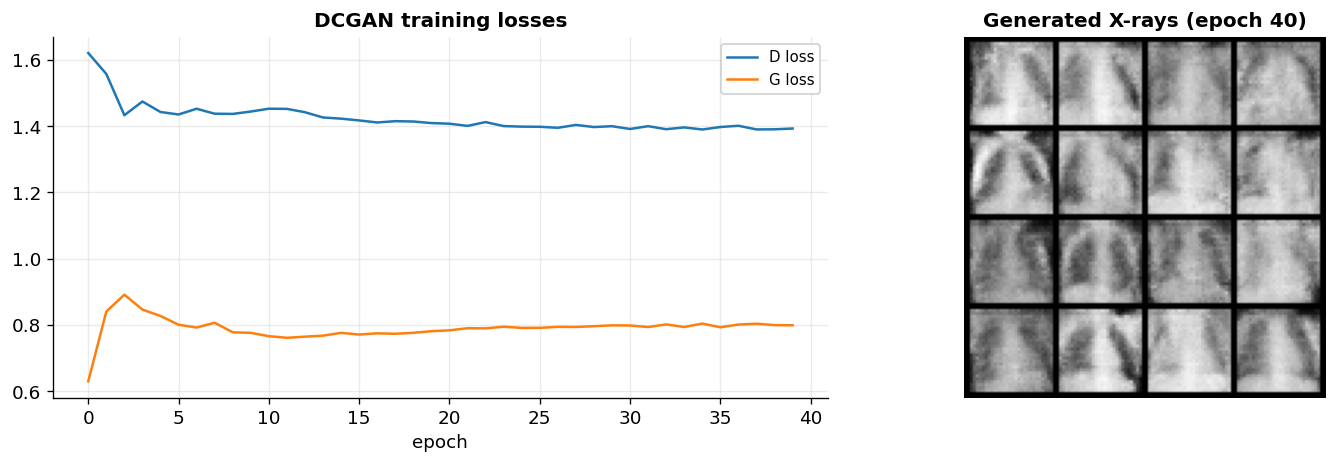

In [ ]:
# Loss curves + how generated samples evolve across epochs.
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(hist["d"], label="D loss"); ax[0].plot(hist["g"], label="G loss")
ax[0].set_xlabel("epoch"); ax[0].set_title("DCGAN training losses"); ax[0].legend()

last = max(hist["snapshots"])
grid = make_grid(hist["snapshots"][last], nrow=4, normalize=True, value_range=(-1, 1))
ax[1].imshow(grid.permute(1, 2, 0).numpy()[:, :, 0], cmap="gray")
ax[1].axis("off"); ax[1].set_title(f"Generated X-rays (epoch {last})")
plt.tight_layout(); plt.show()

4. Real vs. generated - visual comparison

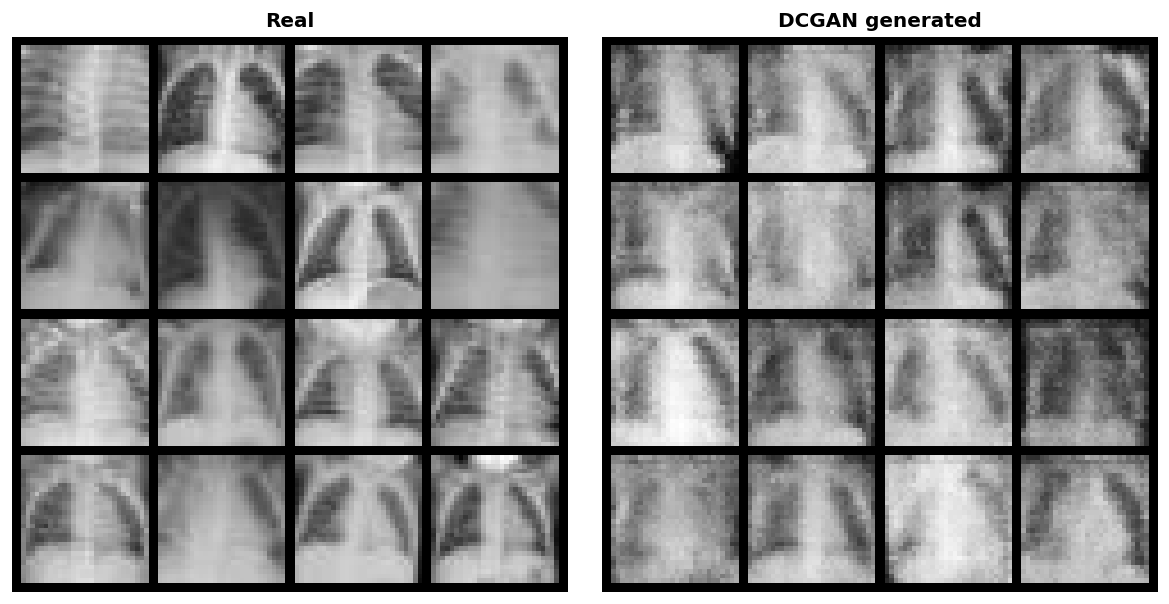

In [ ]:
G.eval()
with torch.no_grad():
    fake_sample = G(torch.randn(16, Z_DIM, device=DEVICE)).cpu()
real_sample = torch.stack([all_images[i][0]
                           for i in np.random.choice(len(all_images), 16, replace=False)])

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
for a, imgs, title in zip(ax, [real_sample, fake_sample], ["Real", "DCGAN generated"]):
    g = make_grid(imgs, nrow=4, normalize=True, value_range=(-1, 1))
    a.imshow(g.permute(1, 2, 0).numpy()[:, :, 0], cmap="gray")
    a.set_title(title); a.axis("off")
plt.tight_layout(); plt.show()

5. Quantitative evaluation - Fréechet Inception Distance


In [1]:
@torch.no_grad()
def compute_fid(gen, real_loader, n_samples=1000, z_dim=Z_DIM):
    """Fréchet Inception Distance between real images and generator output."""
    from torchmetrics.image.fid import FrechetInceptionDistance
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(DEVICE)

    def to_inception(batch):
        # map [-1,1] -> [0,1], grayscale -> RGB, resize to 299
        b = ((batch + 1) / 2).clamp(0, 1).repeat(1, 3, 1, 1)
        return F.interpolate(b, size=(299, 299), mode="bilinear", align_corners=False)

    seen = 0
    for real, _ in real_loader:
        fid.update(to_inception(real.to(DEVICE)), real=True)
        seen += real.size(0)
        if seen >= n_samples: break

    gen.eval(); made = 0
    while made < n_samples:
        bs = min(100, n_samples - made)
        fake = gen(torch.randn(bs, z_dim, device=DEVICE))
        fid.update(to_inception(fake), real=False)
        made += bs
    return float(fid.compute())

fid_uncond = compute_fid(G, loader)

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 283MB/s]


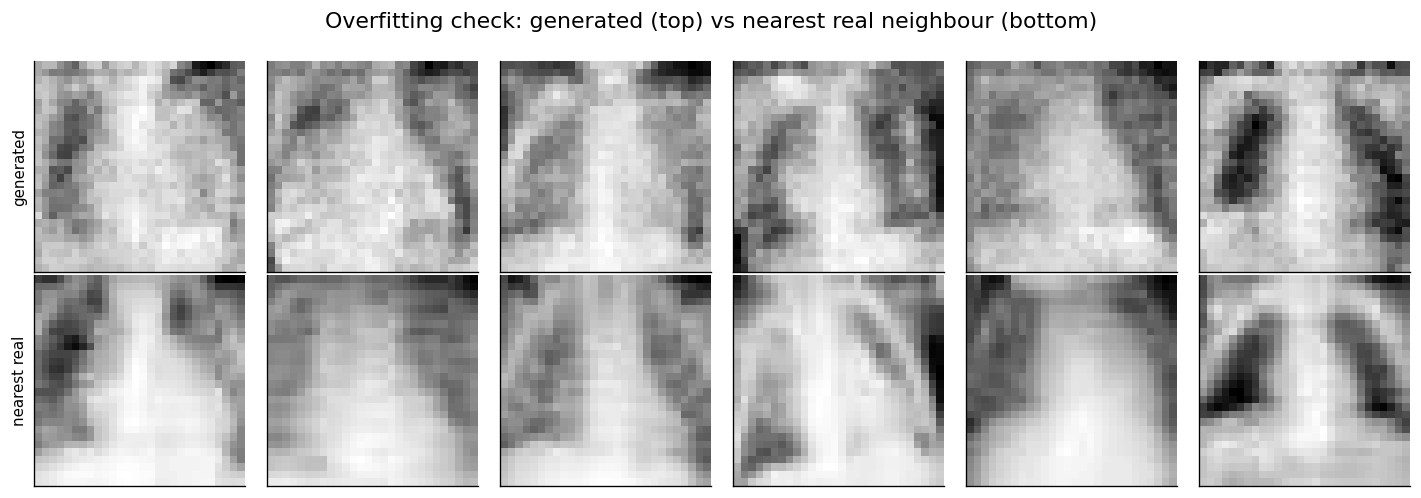

In [ ]:
# Overfitting check — nearest-neighbour test (Unit 5 lecture: "Checking overfitting").
# Each generated X-ray is matched to its closest REAL image by pixel-space L2 distance.
# If the neighbours look clearly different from the generated images, the GAN is
# synthesising new samples rather than memorising the training set.
@torch.no_grad()
def nearest_neighbour_check(gen, real_pool, n_show=6, z_dim=Z_DIM):
    gen.eval()
    fake = gen(torch.randn(n_show, z_dim, device=DEVICE)).cpu()
    real_flat = real_pool.view(len(real_pool), -1)
    fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 4.2))
    for j in range(n_show):
        dist = (real_flat - fake[j].view(1, -1)).pow(2).sum(1)
        neigh = real_pool[int(dist.argmin())]
        axes[0, j].imshow(((fake[j, 0] + 1) / 2).clamp(0, 1).numpy(), cmap="gray")
        axes[1, j].imshow(((neigh[0] + 1) / 2).clamp(0, 1).numpy(), cmap="gray")
    for ax in axes.ravel():
        ax.set_xticks([]); ax.set_yticks([])
    axes[0, 0].set_ylabel("generated", fontsize=9)
    axes[1, 0].set_ylabel("nearest real", fontsize=9)
    plt.suptitle("Overfitting check: generated (top) vs nearest real neighbour (bottom)")
    plt.tight_layout(); plt.show()

# Build a real image pool to search over (subsampled for speed).
pool_idx = np.random.choice(len(all_images), 2000, replace=False)
real_pool = torch.stack([all_images[i][0] for i in pool_idx])
nearest_neighbour_check(G, real_pool)

Generated-sample diversity (mean pairwise L2): 8.444


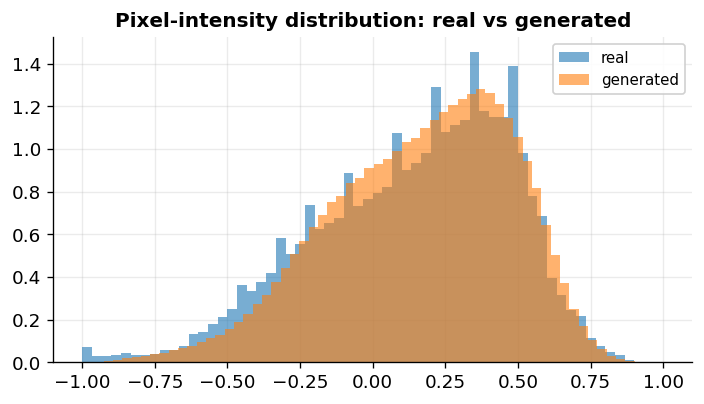

In [ ]:
# --- Extra real-vs-generated checks: sample diversity + pixel-intensity match ---
# (diversity guards against mode collapse; the histogram checks the grey-level distribution)
@torch.no_grad()
def generation_diversity(gen, n=64, z_dim=Z_DIM):
    """Mean pairwise L2 distance among generated images; near-zero would signal collapse."""
    gen.eval()
    flat = gen(torch.randn(n, z_dim, device=DEVICE)).view(n, -1)
    return torch.cdist(flat, flat).triu(1).sum().item() / (n * (n - 1) / 2)

print(f"Generated-sample diversity (mean pairwise L2): {generation_diversity(G):.3f}")

G.eval()
with torch.no_grad():
    fake_px = G(torch.randn(512, Z_DIM, device=DEVICE)).cpu().numpy().ravel()
real_px = real_pool.numpy().ravel()
plt.figure(figsize=(6, 3.5))
plt.hist(real_px, bins=60, density=True, alpha=.6, label="real")
plt.hist(fake_px, bins=60, density=True, alpha=.6, label="generated")
plt.title("Pixel-intensity distribution: real vs generated"); plt.legend()
plt.tight_layout(); plt.show()

## 6. Reflection on the synthetic X-rays

The unconditional DCGAN produces images that are recognisably chest X-rays: the rib cage, the
two lung fields and the central mediastinal shadow sit in roughly the right place. Up close the
samples are grainy and the fine lung markings are lost, which is what we would expect at 28x28
with a small model. The FID of about 155 looks high in absolute terms, but FID is measured
through an InceptionV3 network trained on natural colour photographs, so grayscale medical images
at this resolution always score high; it is most useful here as a relative number rather than an
absolute quality score.

The conditional model reaches a comparable FID (about 153) while adding what the unconditional
model cannot do - it generates a chosen class on demand. The per-class samples follow the
expected radiological pattern, with the normal row showing clearer lung fields and the pneumonia
row appearing hazier, reflecting the increased opacity seen in real pneumonia. The
nearest-neighbour check shows the generated images are not copies of individual training scans,
and the diversity score stays well above zero, so the network is synthesising varied images
rather than collapsing or memorising. The main limitation is sharpness; a higher resolution or
longer training would be the obvious next step.

7. Extension - Conditional GAN (class-controlled generation)

In [ ]:
N_CLASSES = len(CLASS_NAMES)
EMB = 16

class CondGenerator(nn.Module):
    def __init__(self, z_dim=Z_DIM, base=128, n_cls=N_CLASSES, emb=EMB):
        super().__init__()
        self.label_emb = nn.Embedding(n_cls, emb)
        self.seed = nn.Linear(z_dim + emb, base * 7 * 7)
        self.base = base
        self.upsample = nn.Sequential(
            nn.BatchNorm2d(base), nn.ReLU(True),
            nn.ConvTranspose2d(base, base // 2, 4, 2, 1),
            nn.BatchNorm2d(base // 2), nn.ReLU(True),
            nn.ConvTranspose2d(base // 2, base // 4, 4, 2, 1),
            nn.BatchNorm2d(base // 4), nn.ReLU(True),
            nn.Conv2d(base // 4, IMG_CH, 3, 1, 1), nn.Tanh())

    def forward(self, z, y):
        x = torch.cat([z, self.label_emb(y)], dim=1)
        return self.upsample(self.seed(x).view(-1, self.base, 7, 7))


class CondDiscriminator(nn.Module):
    def __init__(self, base=32, n_cls=N_CLASSES, emb=EMB, drop=0.3):
        super().__init__()
        self.label_emb = nn.Embedding(n_cls, emb)
        self.body = nn.Sequential(
            nn.Conv2d(IMG_CH, base, 4, 2, 1),
            nn.LeakyReLU(0.2, True), nn.Dropout2d(drop),
            nn.Conv2d(base, base * 2, 4, 2, 1),
            nn.BatchNorm2d(base * 2), nn.LeakyReLU(0.2, True))
        self.head = nn.Sequential(
            nn.Linear(base * 2 * 7 * 7 + emb, 128), nn.LeakyReLU(0.2, True),
            nn.Linear(128, 1), nn.Sigmoid())

    def forward(self, x, y):
        feat = self.body(x).flatten(1)
        return self.head(torch.cat([feat, self.label_emb(y)], dim=1))

In [ ]:
def train_cgan(gen, disc, loader, epochs=40, z_dim=Z_DIM, g_lr=2e-4, real_label=0.9):
    """Train the conditional DCGAN: generator and discriminator both see the class label."""
    gen, disc = gen.to(DEVICE), disc.to(DEVICE)
    bce = nn.BCELoss()
    opt_g = torch.optim.Adam(gen.parameters(),  lr=g_lr,       betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(disc.parameters(), lr=g_lr * 0.5, betas=(0.5, 0.999))
    d_hist, g_hist = [], []
    for ep in range(1, epochs + 1):
        d_run = g_run = steps = 0
        for real, y in loader:
            real = real.to(DEVICE); y = y.view(-1).long().to(DEVICE); bs = real.size(0)
            real_y = torch.full((bs, 1), real_label, device=DEVICE)
            fake_y = torch.zeros((bs, 1), device=DEVICE)

            disc.zero_grad()
            z = torch.randn(bs, z_dim, device=DEVICE)
            y_fake = torch.randint(0, N_CLASSES, (bs,), device=DEVICE)
            fake = gen(z, y_fake).detach()
            d_loss = bce(disc(real, y), real_y) + bce(disc(fake, y_fake), fake_y)
            d_loss.backward(); opt_d.step()

            gen.zero_grad()
            z = torch.randn(bs, z_dim, device=DEVICE)
            y_fake = torch.randint(0, N_CLASSES, (bs,), device=DEVICE)
            g_loss = bce(disc(gen(z, y_fake), y_fake), real_y)
            g_loss.backward(); opt_g.step()
            d_run += d_loss.item(); g_run += g_loss.item(); steps += 1
        d_hist.append(d_run / steps); g_hist.append(g_run / steps)
        if ep % 5 == 0 or ep == epochs:
            print(f"epoch {ep:3d} | D {d_hist[-1]:.3f} | G {g_hist[-1]:.3f}")
    return d_hist, g_hist

torch.manual_seed(SEED)
cG = CondGenerator();     cG.apply(init_dcgan_weights)
cD = CondDiscriminator(); cD.apply(init_dcgan_weights)
cd_hist, cg_hist = train_cgan(cG, cD, loader, epochs=EPOCHS)

epoch   5 | D 1.336 | G 0.873
epoch  10 | D 1.315 | G 0.916
epoch  15 | D 1.272 | G 0.952
epoch  20 | D 1.258 | G 0.999
epoch  25 | D 1.231 | G 1.020
epoch  30 | D 1.219 | G 1.039
epoch  35 | D 1.219 | G 1.055
epoch  40 | D 1.214 | G 1.039


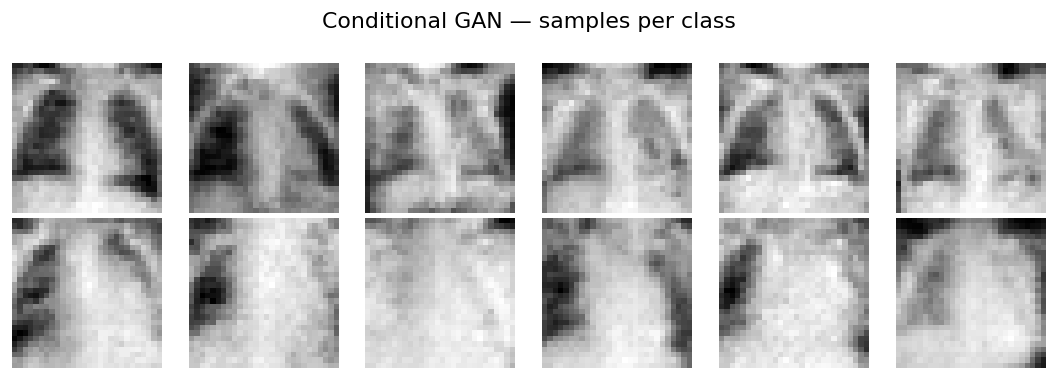

In [ ]:
# Generate a row of samples for each class on demand.
cG.eval()
fig, axes = plt.subplots(N_CLASSES, 6, figsize=(9, 1.6 * N_CLASSES))
for ci in range(N_CLASSES):
    with torch.no_grad():
        z = torch.randn(6, Z_DIM, device=DEVICE)
        y = torch.full((6,), ci, dtype=torch.long, device=DEVICE)
        imgs = cG(z, y).cpu()
    for j in range(6):
        a = axes[ci, j]
        a.imshow(((imgs[j, 0] + 1) / 2).clamp(0, 1).numpy(), cmap="gray"); a.axis("off")
    axes[ci, 0].set_ylabel(CLASS_NAMES[ci], rotation=0, ha="right", va="center")
plt.suptitle("Conditional GAN — samples per class")
plt.tight_layout(); plt.show()

In [ ]:
# FID of the conditional model (labels drawn at random) for a like-for-like comparison.
class _CondWrap(nn.Module):
    def __init__(self, g): super().__init__(); self.g = g
    def forward(self, z):
        y = torch.randint(0, N_CLASSES, (z.size(0),), device=z.device)
        return self.g(z, y)

fid_cond = compute_fid(_CondWrap(cG).to(DEVICE), loader)
print(f"Conditional GAN FID: {fid_cond:.2f}   |  Unconditional FID: {fid_uncond:.2f}")

Conditional GAN FID: 153.02   |  Unconditional FID: 154.76
